Curse of Dimensionality


Curse of Dimensionality বলতে বোঝায়—Machine Learning dataset-এ feature বা dimension-এর সংখ্যা অনেক বেড়ে গেলে model-এর জন্য data থেকে useful pattern শেখা কঠিন হয়ে যায়।

একটি সহজ উদাহরণ
ধরো, তুমি কোনো student-এর result predict করতে চাও।

প্রথমে মাত্র 2টি feature:
- Study Hours
- Attendance

এখন data-কে 2D graph-এ সহজেই দেখা যায়।
কিন্তু যদি feature হয় 100টি:
- Study Hours
- Attendance
- Sleep
- Assignment
- Quiz
- Facebook usage
- YouTube usage
- ইত্যাদি...
তখন data একটি 100-dimensional space-এ ছড়িয়ে পড়ে। একই পরিমাণ data থাকলে এই বিশাল space-এর অনেক জায়গা ফাঁকা থাকে।
এটাই মূল সমস্যা।

PCA — Principal Component Analysis
PCA (Principal Component Analysis) হলো একটি Dimensionality Reduction technique। এর কাজ হলো অনেকগুলো feature-এর information যতটা সম্ভব ধরে রেখে কম সংখ্যক নতুন feature/component-এ data represent করা।
সহজভাবে:
অনেক feature → PCA → কম feature, কিন্তু গুরুত্বপূর্ণ information যতটা সম্ভব রাখা।

সহজ উদাহরণ
ধরো তোমার dataset-এ 5টি feature আছে:
Height
Weight
Age
BMI
Body Fat

এগুলোর মধ্যে কিছু feature-এর information একে অপরের সাথে related হতে পারে।
PCA এগুলোকে transform করে নতুন কিছু Principal Components তৈরি করতে পারে:


5 Features


    ↓


   PCA

    PCA — Principal Component Analysis
PCA (Principal Component Analysis) হলো একটি Dimensionality Reduction technique। এর কাজ হলো অনেকগুলো feature-এর information যতটা সম্ভব ধরে রেখে কম সংখ্যক নতুন feature/component-এ data represent করা।
সহজভাবে:
অনেক feature → PCA → কম feature, কিন্তু গুরুত্বপূর্ণ information যতটা সম্ভব রাখা।

সহজ উদাহরণ
ধরো তোমার dataset-এ 5টি feature আছে:
Height
Weight
Age
BMI
Body Fat

এগুলোর মধ্যে কিছু feature-এর information একে অপরের সাথে related হতে পারে।
PCA এগুলোকে transform করে নতুন কিছু Principal Components তৈরি করতে পারে:

5 Features

   ↓

   PCA

   ↓

2 Principal Components

এখন 5টি original feature-এর বদলে 2টি component ব্যবহার করেও dataset-এর বেশিরভাগ গুরুত্বপূর্ণ variation রাখা যেতে পারে।
Principal Component কী?
Principal Component (PC) হলো original features-এর combination থেকে তৈরি একটি নতুন feature।

2 Principal Components



এখন 5টি original feature-এর বদলে 2টি component ব্যবহার করেও dataset-এর বেশিরভাগ গুরুত্বপূর্ণ variation রাখা যেতে পারে।
Principal Component কী?
Principal Component (PC) হলো original features-এর combination থেকে তৈরি একটি নতুন feature।

# How to Select Features (Basic way )

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [42]:
from sklearn.decomposition import PCA


In [43]:
df=load_breast_cancer(as_frame=True).frame
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [44]:
df.shape

(569, 31)

In [45]:
X=df.drop('target',axis=1)
y=df['target']

In [46]:
scaler=StandardScaler()
X_scaler=scaler.fit_transform(X)

In [47]:
np.set_printoptions(suppress=True)

pca_full=PCA(n_components=None)

X_pca_full=pca_full.fit_transform(X_scaler)
explained=pca_full.explained_variance_ratio_

In [48]:
explained

array([0.44272026, 0.18971182, 0.09393163, 0.06602135, 0.05495768,
       0.04024522, 0.02250734, 0.01588724, 0.01389649, 0.01168978,
       0.00979719, 0.00870538, 0.00804525, 0.00523366, 0.00313783,
       0.00266209, 0.00197997, 0.00175396, 0.00164925, 0.00103865,
       0.0009991 , 0.00091465, 0.00081136, 0.00060183, 0.00051604,
       0.00027259, 0.00023002, 0.00005298, 0.00002496, 0.00000443])

In [49]:
cum_variable=np.cumsum(explained)
cum_variable

array([0.44272026, 0.63243208, 0.72636371, 0.79238506, 0.84734274,
       0.88758796, 0.9100953 , 0.92598254, 0.93987903, 0.95156881,
       0.961366  , 0.97007138, 0.97811663, 0.98335029, 0.98648812,
       0.98915022, 0.99113018, 0.99288414, 0.9945334 , 0.99557204,
       0.99657114, 0.99748579, 0.99829715, 0.99889898, 0.99941502,
       0.99968761, 0.99991763, 0.99997061, 0.99999557, 1.        ])

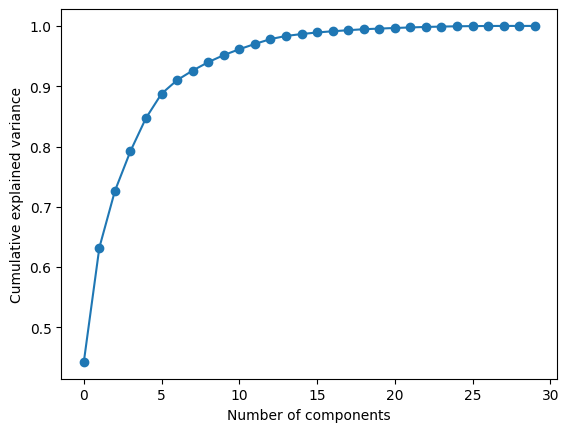

In [50]:
plt.plot(cum_variable,marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

In [51]:
X_train,X_test,y_train,y_test=train_test_split(X_pca_full,y,test_size=0.2,random_state=42)

# Without use PCA

In [52]:
pipe_no_pca=Pipeline([
     ("scaler",StandardScaler()),
     ("clf",LogisticRegression(max_iter=500))

])

pipe_no_pca.fit(X_train,y_train)
y_pred=pipe_no_pca.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9473684210526315
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        43
           1       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [55]:
print(accuracy_score(y_test,y_pred))

0.9736842105263158


# with PCA

In [53]:
pipe_with_pca=Pipeline([
     ("scaler",StandardScaler()),
     ("pca",PCA(n_components=0.95)),
     ("clf",LogisticRegression(max_iter=500))

])

In [54]:
pipe_with_pca.fit(X_train,y_train)
y_pred=pipe_with_pca.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9736842105263158
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [56]:
print(accuracy_score(y_test,y_pred))

0.9736842105263158
